<a href="https://colab.research.google.com/github/Rakmik/NM/blob/main/%D0%9B%D0%A0%E2%84%969_%D0%97%D0%B0%D0%B3%D0%B8%D0%BD%D0%B0%D0%B9%D0%BA%D0%BE_%D0%9F%D0%B0%D0%B2%D0%BB%D0%BE_%D0%A4%D0%86%D0%A2_2_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Загинайко Павло
#Варіант 8

#Був присутній на парі

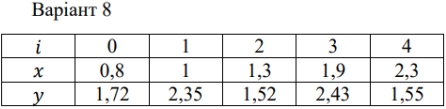

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

#Вхідні дані

In [66]:
x = np.array([0.8, 1.0, 1.3, 1.9, 2.3])
y = np.array([1.72, 2.35, 1.52, 2.43, 1.55])

n = len(x) - 1
h = np.diff(x)
a = y.copy()
b = np.zeros(n)
d = np.zeros(n)
c = np.zeros(n + 1)

#Інтерполяція сплайнами

In [67]:
alpha = np.zeros(n)
for i in range(1, n):
    alpha[i] = (3 / h[i]) * (a[i+1] - a[i]) - (3 / h[i-1]) * (a[i] - a[i-1])

l = np.ones(n + 1)
mu = np.zeros(n)
z = np.zeros(n + 1)

for i in range(1, n):
    l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
    mu[i] = h[i] / l[i]
    z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]

c[n] = 0

for j in range(n-1, -1, -1):
    c[j] = z[j] - mu[j] * c[j+1]
    b[j] = (a[j+1] - a[j]) / h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
    d[j] = (c[j+1] - c[j]) / (3 * h[j])

#Результати

In [68]:
print(" Коефіцієнти сплайну (Розрахунок)")
for i in range(n):
    print(f"Відрізок {i+1} [{x[i]}, {x[i+1]}]:")
    print(f"  S_{i}(x) = {a[i]} + {b[i]:.4f}(x - {x[i]}) + {c[i]:.4f}(x - {x[i]})^2 + {d[i]:.4f}(x - {x[i]})^3")

 Коефіцієнти сплайну (Розрахунок)
Відрізок 1 [0.8, 1.0]:
  S_0(x) = 1.72 + 4.6146(x - 0.8) + 0.0000(x - 0.8)^2 + -36.6160(x - 0.8)^3
Відрізок 2 [1.0, 1.3]:
  S_1(x) = 2.35 + 0.2207(x - 1.0) + -21.9696(x - 1.0)^2 + 40.0389(x - 1.0)^3
Відрізок 3 [1.3, 1.9]:
  S_2(x) = 1.52 + -2.1506(x - 1.3) + 14.0654(x - 1.3)^2 + -13.2555(x - 1.3)^3
Відрізок 4 [1.9, 2.3]:
  S_3(x) = 2.43 + 0.4119(x - 1.9) + -9.7946(x - 1.9)^2 + 8.1622(x - 1.9)^3


# Обчислення

In [69]:
x_fine = np.linspace(x.min(), x.max(), 500)

y_manual = []
for val in x_fine:
    idx = np.searchsorted(x, val) - 1
    idx = max(0, min(idx, n - 1))
    dx = val - x[idx]
    y_manual.append(a[idx] + b[idx]*dx + c[idx]*(dx**2) + d[idx]*(dx**3))

#Побудова графіка

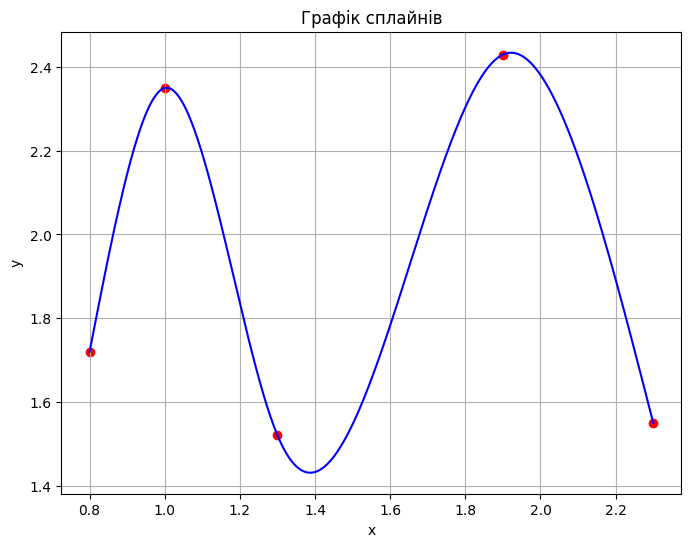

In [75]:
plt.figure(1, figsize=(8, 6))
y_manual = []
for val in x_fine:
    idx = np.searchsorted(x, val) - 1
    idx = max(0, min(idx, n - 1))
    dx = val - x[idx]
    y_val = a[idx] + b[idx]*dx + c[idx]*(dx**2) + d[idx]*(dx**3)
    y_manual.append(y_val)

plt.plot(x_fine, y_manual, 'b-', label='Сплайн')
plt.scatter(x, y, color='red', label='Точки (Вар 8)')
plt.title('Графік сплайнів')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

#Перевірка CubicSpline

In [71]:
cs = CubicSpline(x, y, bc_type='natural')
y_scipy = cs(x_fine)

In [76]:
print("Коефіцієнти CubicSpline")
for i in range(len(x)-1):
    # У SciPy коефіцієнти йдуть у порядку: [x^3, x^2, x^1, x^0]
    coeffs = cs.c[:, i]
    print(f"Інтервал {i+1} [{x[i]}, {x[i+1]}]:")
    print(f"  S(x) = {coeffs[0]:.4f}(x-{x[i]})^3 + {coeffs[1]:.4f}(x-{x[i]})^2 + {coeffs[2]:.4f}(x-{x[i]}) + {coeffs[3]:.4f}")

Коефіцієнти CubicSpline
Інтервал 1 [0.8, 1.0]:
  S(x) = -36.6160(x-0.8)^3 + -0.0000(x-0.8)^2 + 4.6146(x-0.8) + 1.7200
Інтервал 2 [1.0, 1.3]:
  S(x) = 40.0389(x-1.0)^3 + -21.9696(x-1.0)^2 + 0.2207(x-1.0) + 2.3500
Інтервал 3 [1.3, 1.9]:
  S(x) = -13.2555(x-1.3)^3 + 14.0654(x-1.3)^2 + -2.1506(x-1.3) + 1.5200
Інтервал 4 [1.9, 2.3]:
  S(x) = 8.1622(x-1.9)^3 + -9.7946(x-1.9)^2 + 0.4119(x-1.9) + 2.4300


#Побудова графіка

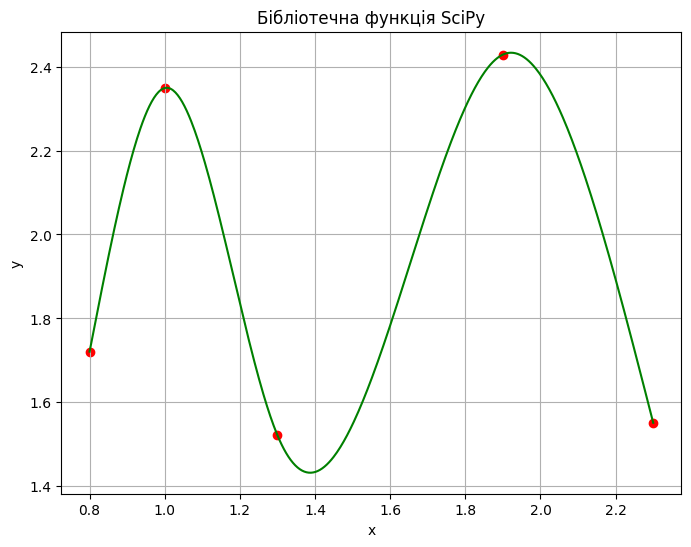

In [73]:
plt.figure(2, figsize=(8, 6))
cs = CubicSpline(x, y, bc_type='natural')
y_scipy = cs(x_fine)

plt.plot(x_fine, y_scipy, 'g-', label='SciPy CubicSpline')
plt.scatter(x, y, color='red', label='Точки (Вар 8)')
plt.title('Бібліотечна функція SciPy')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)